# **DATASETS**

In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# **Preprocessing (normalization and padding values)**

In [13]:
df = pd.read_csv('/content/content/CICIDS2017_no_sampling (1).csv')

In [14]:
df.Label.value_counts()

,count
Label,
BENIGN,1841023
DoS,380688
PortScan,158930
Bot,1966
Web Attack � Brute Force,1507
Web Attack � XSS,652
Infiltration,36
Web Attack � Sql Injection,21
Heartbleed,11


In [15]:
# Min-max normalization
numeric_features = df.dtypes[df.dtypes != 'object'].index
df[numeric_features] = df[numeric_features].apply(
    lambda x: (x - x.min()) / (x.max()-x.min()))
# Fill empty values by 0
df = df.fillna(0)

# **split train set and test set**

In [16]:
# Create a temporary DataFrame to work on, dropping rows with NaN in 'Label'
df_temp = df.copy()
df_temp.dropna(subset=['Label'], inplace=True)

# Convert the 'Label' column to string type to ensure uniformity for LabelEncoder
df_temp['Label'] = df_temp['Label'].astype(str)

labelencoder = LabelEncoder()
df_temp['Label'] = labelencoder.fit_transform(df_temp['Label'])

X = df_temp.drop(['Label'],axis=1).values
y = df_temp['Label'].values
# Ensure y is explicitly integer type for SMOTE compatibility
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, test_size = 0.2, random_state = 0,stratify = y)

In [17]:
# This prints the mapping of labels to numbers
print(dict(zip(labelencoder.classes_, range(len(labelencoder.classes_)))))

{'BENIGN': 0, 'Bot': 1, 'DoS': 2, 'Heartbleed': 3, 'Infiltration': 4, 'PortScan': 5, 'Web Attack � Brute Force': 6, 'Web Attack � Sql Injection': 7, 'Web Attack � XSS': 8}


In [18]:
X_train.shape
pd.Series(y_train).value_counts()

,count
0,1472818
2,304550
5,127144
1,1573
6,1205
8,522
4,29
7,17
3,9


# **Machine learning model training**

Accuracy of DT: 0.9982367752905337
Precision of DT: 0.9982273304981253
Recall of DT: 0.9982367752905337
F1-score of DT: 0.9982310771227985
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368205
           1       0.83      0.80      0.81       393
           2       1.00      1.00      1.00     76138
           3       1.00      1.00      1.00         2
           4       0.75      0.43      0.55         7
           5       0.99      0.99      0.99     31786
           6       0.75      0.76      0.76       302
           7       0.60      0.75      0.67         4
           8       0.42      0.41      0.42       130

    accuracy                           1.00    476967
   macro avg       0.82      0.79      0.80    476967
weighted avg       1.00      1.00      1.00    476967



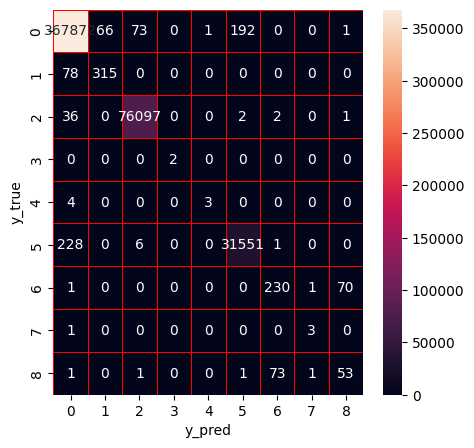

In [19]:
# Decision tree training and prediction
dt = DecisionTreeClassifier(random_state = 0)
dt.fit(X_train,y_train)
dt_score=dt.score(X_test,y_test)
y_predict=dt.predict(X_test)
y_true=y_test
print('Accuracy of DT: '+ str(dt_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of DT: '+(str(precision)))
print('Recall of DT: '+(str(recall)))
print('F1-score of DT: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [20]:
dt_train=dt.predict(X_train)
dt_test=dt.predict(X_test)

Accuracy of RF: 0.9984401436577374
Precision of RF: 0.9984005882223913
Recall of RF: 0.9984401436577374
F1-score of RF: 0.9984144158524655
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368205
           1       0.90      0.77      0.83       393
           2       1.00      1.00      1.00     76138
           3       1.00      1.00      1.00         2
           4       1.00      0.86      0.92         7
           5       0.99      1.00      0.99     31786
           6       0.72      0.77      0.74       302
           7       0.00      0.00      0.00         4
           8       0.36      0.29      0.32       130

    accuracy                           1.00    476967
   macro avg       0.78      0.74      0.76    476967
weighted avg       1.00      1.00      1.00    476967



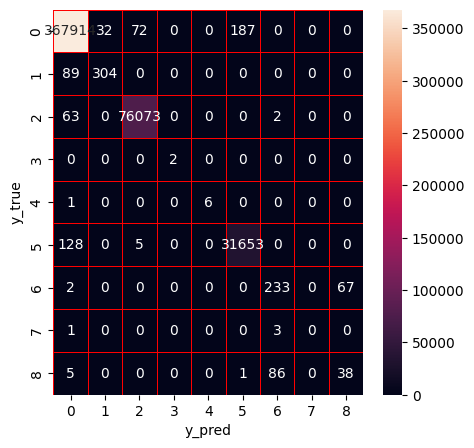

In [21]:
# Random Forest training and prediction
rf = RandomForestClassifier(random_state = 0)
rf.fit(X_train,y_train)
rf_score=rf.score(X_test,y_test)
y_predict=rf.predict(X_test)
y_true=y_test
print('Accuracy of RF: '+ str(rf_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of RF: '+(str(precision)))
print('Recall of RF: '+(str(recall)))
print('F1-score of RF: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [22]:
rf_train=rf.predict(X_train)
rf_test=rf.predict(X_test)

Accuracy of ET: 0.9981130770053274
Precision of ET: 0.9980842138212185
Recall of ET: 0.9981130770053274
F1-score of ET: 0.9980933340707472
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368205
           1       0.86      0.73      0.79       393
           2       1.00      1.00      1.00     76138
           3       1.00      1.00      1.00         2
           4       1.00      0.71      0.83         7
           5       0.99      0.99      0.99     31786
           6       0.72      0.74      0.73       302
           7       0.00      0.00      0.00         4
           8       0.37      0.35      0.36       130

    accuracy                           1.00    476967
   macro avg       0.77      0.72      0.75    476967
weighted avg       1.00      1.00      1.00    476967



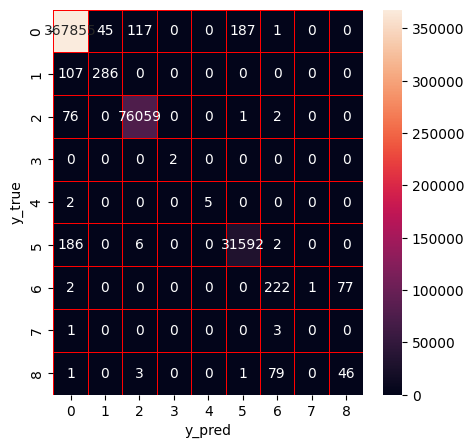

In [23]:
# Extra trees training and prediction
et = ExtraTreesClassifier(random_state = 0)
et.fit(X_train,y_train)
et_score=et.score(X_test,y_test)
y_predict=et.predict(X_test)
y_true=y_test
print('Accuracy of ET: '+ str(et_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of ET: '+(str(precision)))
print('Recall of ET: '+(str(recall)))
print('F1-score of ET: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [24]:
et_train=et.predict(X_train)
et_test=et.predict(X_test)

Accuracy of XGBoost: 0.9806296871691333
Precision of XGBoost: 0.9946833983167507
Recall of XGBoost: 0.9806296871691333
F1-score of XGBoost: 0.987549592720802
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    368205
           1       0.78      0.61      0.69       393
           2       0.99      0.98      0.99     76138
           3       1.00      1.00      1.00         2
           4       1.00      0.57      0.73         7
           5       0.99      1.00      0.99     31786
           6       0.03      0.19      0.06       302
           7       0.00      0.00      0.00         4
           8       0.00      0.04      0.00       130

    accuracy                           0.98    476967
   macro avg       0.64      0.60      0.60    476967
weighted avg       0.99      0.98      0.99    476967



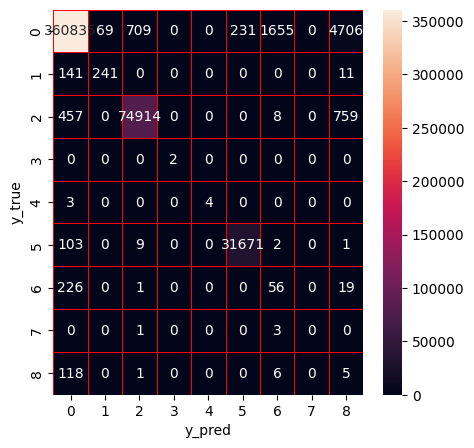

In [25]:
# XGboost training and prediction
xg = xgb.XGBClassifier(n_estimators = 10)
xg.fit(X_train,y_train)
xg_score=xg.score(X_test,y_test)
y_predict=xg.predict(X_test)
y_true=y_test
print('Accuracy of XGBoost: '+ str(xg_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of XGBoost: '+(str(precision)))
print('Recall of XGBoost: '+(str(recall)))
print('F1-score of XGBoost: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [26]:
xg_train=xg.predict(X_train)
xg_test=xg.predict(X_test)

# **Stacking model construction (ensemble for 4 base learners)**

In [27]:
# Use the outputs of 4 base models to construct a new ensemble model
base_predictions_train = pd.DataFrame( {
    'DecisionTree': dt_train.ravel(),
        'RandomForest': rf_train.ravel(),
     'ExtraTrees': et_train.ravel(),
     'XgBoost': xg_train.ravel(),
    })
base_predictions_train.head(5)

,DecisionTree,RandomForest,ExtraTrees,XgBoost
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,2,2,2,2
4,0,0,0,0


In [28]:
dt_train=dt_train.reshape(-1, 1)
et_train=et_train.reshape(-1, 1)
rf_train=rf_train.reshape(-1, 1)
xg_train=xg_train.reshape(-1, 1)
dt_test=dt_test.reshape(-1, 1)
et_test=et_test.reshape(-1, 1)
rf_test=rf_test.reshape(-1, 1)
xg_test=xg_test.reshape(-1, 1)

In [29]:
x_train = np.concatenate(( dt_train, et_train, rf_train, xg_train), axis=1)
x_test = np.concatenate(( dt_test, et_test, rf_test, xg_test), axis=1)

In [30]:
stk = xgb.XGBClassifier().fit(x_train, y_train)

Accuracy of Stacking: 0.7719716458371334
Precision of Stacking: 0.5959402219764925
Recall of Stacking: 0.7719716458371334
F1-score of Stacking: 0.6726295235891907
              precision    recall  f1-score   support

           0       0.77      1.00      0.87    368205
           1       0.00      0.00      0.00       393
           2       0.00      0.00      0.00     76138
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         7
           5       0.00      0.00      0.00     31786
           6       0.00      0.00      0.00       302
           7       0.00      0.00      0.00         4
           8       0.00      0.00      0.00       130

    accuracy                           0.77    476967
   macro avg       0.09      0.11      0.10    476967
weighted avg       0.60      0.77      0.67    476967



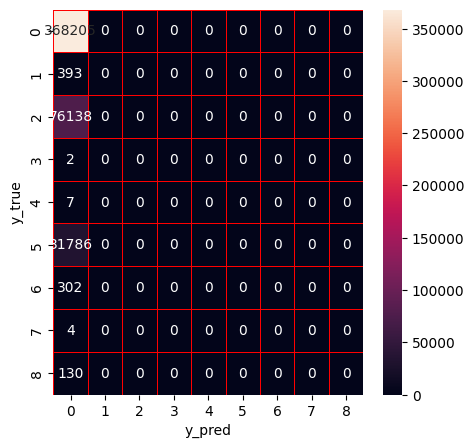

In [31]:
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

# **Feature Selection**

In [32]:
# Save the feature importance lists generated by four tree-based algorithms
dt_feature = dt.feature_importances_
rf_feature = rf.feature_importances_
et_feature = et.feature_importances_
xgb_feature = xg.feature_importances_

In [33]:
# calculate the average importance value of each feature
avg_feature = (dt_feature + rf_feature + et_feature + xgb_feature)/4

In [34]:
feature=(df.drop(['Label'],axis=1)).columns.values
print ("Features sorted by their score:")
print (sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True))

Features sorted by their score:
[(np.float64(0.1216), ' Bwd Packet Length Std'), (np.float64(0.0654), ' Average Packet Size'), (np.float64(0.0598), ' Destination Port'), (np.float64(0.053), ' Packet Length Variance'), (np.float64(0.0511), ' Fwd IAT Max'), (np.float64(0.0467), ' Flow IAT Std'), (np.float64(0.0444), 'Bwd Packet Length Max'), (np.float64(0.037), ' Fwd Packet Length Mean'), (np.float64(0.0365), ' Total Length of Bwd Packets'), (np.float64(0.0286), ' Bwd Packet Length Mean'), (np.float64(0.0248), ' PSH Flag Count'), (np.float64(0.0237), 'Init_Win_bytes_forward'), (np.float64(0.0228), ' Avg Bwd Segment Size'), (np.float64(0.0226), ' Packet Length Mean'), (np.float64(0.0199), ' Packet Length Std'), (np.float64(0.0183), ' Fwd IAT Std'), (np.float64(0.0178), ' Flow IAT Max'), (np.float64(0.0171), 'Fwd Packets/s'), (np.float64(0.0164), ' Max Packet Length'), (np.float64(0.0154), ' Bwd Packets/s'), (np.float64(0.0145), ' Init_Win_bytes_backward'), (np.float64(0.0141), ' Bwd Packe

In [35]:
f_list = sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True)

In [36]:
len(f_list)

78

In [37]:
# Select the important features from top-importance to bottom-importance until the accumulated importance reaches 0.9 (out of 1)
Sum = 0
fs = []
for i in range(0, len(f_list)):
    Sum = Sum + f_list[i][0]
    fs.append(f_list[i][1])
    if Sum>=0.9:
        break

In [38]:
print(fs)

[' Bwd Packet Length Std', ' Average Packet Size', ' Destination Port', ' Packet Length Variance', ' Fwd IAT Max', ' Flow IAT Std', 'Bwd Packet Length Max', ' Fwd Packet Length Mean', ' Total Length of Bwd Packets', ' Bwd Packet Length Mean', ' PSH Flag Count', 'Init_Win_bytes_forward', ' Avg Bwd Segment Size', ' Packet Length Mean', ' Packet Length Std', ' Fwd IAT Std', ' Flow IAT Max', 'Fwd Packets/s', ' Max Packet Length', ' Bwd Packets/s', ' Init_Win_bytes_backward', ' Bwd Packet Length Min', ' Flow IAT Min', ' Idle Max', ' Bwd IAT Max', ' ACK Flag Count', 'Total Length of Fwd Packets', ' Subflow Bwd Bytes', 'Fwd PSH Flags', 'Fwd IAT Total', ' Bwd IAT Min', ' Subflow Fwd Bytes', ' Total Fwd Packets', ' Idle Min', ' min_seg_size_forward', ' Min Packet Length']


In [39]:
X_fs = df[fs].values

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X_fs,y, train_size = 0.8, test_size = 0.2, random_state = 0,stratify = y)

In [41]:
X_train.shape

(1907867, 36)

In [42]:
pd.Series(y_train).value_counts()

,count
0,1472818
2,304550
5,127144
1,1573
6,1205
8,522
4,29
7,17
3,9


# **Machine learning model training after feature selection**

Accuracy of DT: 0.9981361393974845
Precision of DT: 0.9981516212600616
Recall of DT: 0.9981361393974845
F1-score of DT: 0.9981426186662261
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368205
           1       0.83      0.80      0.81       393
           2       1.00      1.00      1.00     76138
           3       1.00      1.00      1.00         2
           4       1.00      0.86      0.92         7
           5       0.99      0.99      0.99     31786
           6       0.70      0.67      0.69       302
           7       0.33      0.25      0.29         4
           8       0.40      0.47      0.43       130

    accuracy                           1.00    476967
   macro avg       0.81      0.78      0.79    476967
weighted avg       1.00      1.00      1.00    476967



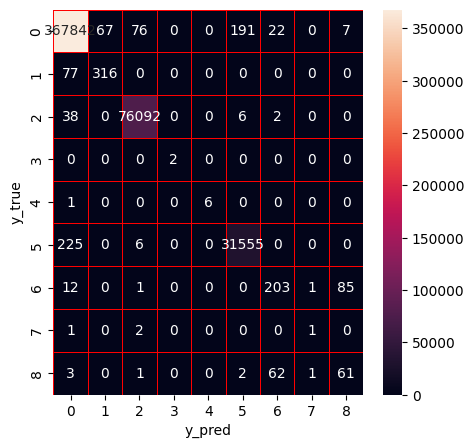

In [43]:
# Decision tree training and prediction
dt = DecisionTreeClassifier(random_state = 0)
dt.fit(X_train,y_train)
dt_score=dt.score(X_test,y_test)
y_predict=dt.predict(X_test)
y_true=y_test
print('Accuracy of DT: '+ str(dt_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of DT: '+(str(precision)))
print('Recall of DT: '+(str(recall)))
print('F1-score of DT: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [44]:
dt_train=dt.predict(X_train)
dt_test=dt.predict(X_test)

Accuracy of RF: 0.9984632060498945
Precision of RF: 0.9984334183355527
Recall of RF: 0.9984632060498945
F1-score of RF: 0.9984427397025474
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368205
           1       0.92      0.77      0.84       393
           2       1.00      1.00      1.00     76138
           3       1.00      1.00      1.00         2
           4       1.00      0.86      0.92         7
           5       0.99      1.00      1.00     31786
           6       0.73      0.73      0.73       302
           7       0.00      0.00      0.00         4
           8       0.38      0.35      0.36       130

    accuracy                           1.00    476967
   macro avg       0.78      0.74      0.76    476967
weighted avg       1.00      1.00      1.00    476967



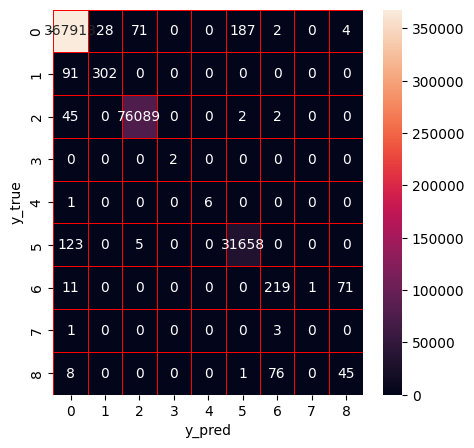

In [45]:
# Random Forest training and prediction
rf = RandomForestClassifier(random_state = 0)
rf.fit(X_train,y_train)
rf_score=rf.score(X_test,y_test)
y_predict=rf.predict(X_test)
y_true=y_test
print('Accuracy of RF: '+ str(rf_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of RF: '+(str(precision)))
print('Recall of RF: '+(str(recall)))
print('F1-score of RF: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [46]:
rf_train=rf.predict(X_train)
rf_test=rf.predict(X_test)

Accuracy of ET: 0.998173877857378
Precision of ET: 0.9981412025212085
Recall of ET: 0.998173877857378
F1-score of ET: 0.9981509363176636
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368205
           1       0.88      0.73      0.80       393
           2       1.00      1.00      1.00     76138
           3       1.00      1.00      1.00         2
           4       1.00      0.57      0.73         7
           5       0.99      0.99      0.99     31786
           6       0.72      0.75      0.73       302
           7       0.00      0.00      0.00         4
           8       0.40      0.36      0.38       130

    accuracy                           1.00    476967
   macro avg       0.78      0.71      0.74    476967
weighted avg       1.00      1.00      1.00    476967



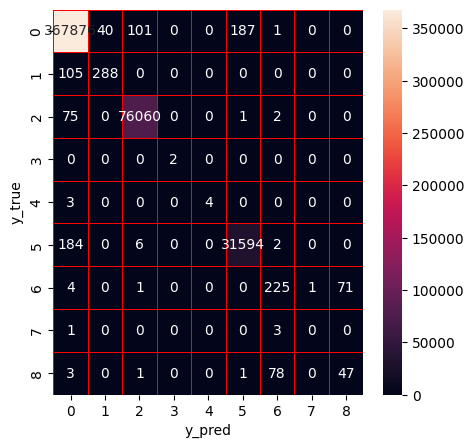

In [47]:
# Extra trees training and prediction
et = ExtraTreesClassifier(random_state = 0)
et.fit(X_train,y_train)
et_score=et.score(X_test,y_test)
y_predict=et.predict(X_test)
y_true=y_test
print('Accuracy of ET: '+ str(et_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of ET: '+(str(precision)))
print('Recall of ET: '+(str(recall)))
print('F1-score of ET: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [48]:
et_train=et.predict(X_train)
et_test=et.predict(X_test)

Accuracy of XGBoost: 0.9902739602530154
Precision of XGBoost: 0.9952188993744899
Recall of XGBoost: 0.9902739602530154
F1-score of XGBoost: 0.9927055642193899
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368205
           1       0.48      0.53      0.50       393
           2       0.99      0.96      0.98     76138
           3       1.00      1.00      1.00         2
           4       1.00      0.71      0.83         7
           5       0.99      1.00      1.00     31786
           6       0.62      0.57      0.60       302
           7       0.00      0.00      0.00         4
           8       0.00      0.07      0.01       130

    accuracy                           0.99    476967
   macro avg       0.68      0.65      0.66    476967
weighted avg       1.00      0.99      0.99    476967



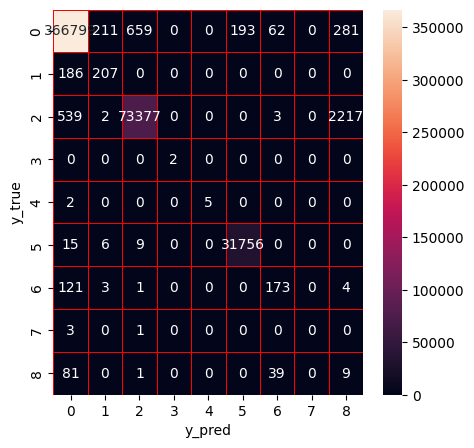

In [49]:
xg = xgb.XGBClassifier(n_estimators = 10)
xg.fit(X_train,y_train)
xg_score=xg.score(X_test,y_test)
y_predict=xg.predict(X_test)
y_true=y_test
print('Accuracy of XGBoost: '+ str(xg_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of XGBoost: '+(str(precision)))
print('Recall of XGBoost: '+(str(recall)))
print('F1-score of XGBoost: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [50]:
xg_train=xg.predict(X_train)
xg_test=xg.predict(X_test)

# Stacking model construction (ensemble for 4 base learners)**bold text**

In [51]:
base_predictions_train = pd.DataFrame( {
    'DecisionTree': dt_train.ravel(),
        'RandomForest': rf_train.ravel(),
     'ExtraTrees': et_train.ravel(),
     'XgBoost': xg_train.ravel(),
    })
base_predictions_train.head(5)

,DecisionTree,RandomForest,ExtraTrees,XgBoost
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,2,2,2,8
4,0,0,0,0


In [52]:
dt_train=dt_train.reshape(-1, 1)
et_train=et_train.reshape(-1, 1)
rf_train=rf_train.reshape(-1, 1)
xg_train=xg_train.reshape(-1, 1)
dt_test=dt_test.reshape(-1, 1)
et_test=et_test.reshape(-1, 1)
rf_test=rf_test.reshape(-1, 1)
xg_test=xg_test.reshape(-1, 1)

In [53]:
x_train = np.concatenate(( dt_train, et_train, rf_train, xg_train), axis=1)
x_test = np.concatenate(( dt_test, et_test, rf_test, xg_test), axis=1)

Accuracy of Stacking: 0.9964819369054883
Precision of Stacking: 0.9963293458083002
Recall of Stacking: 0.9964819369054883
F1-score of Stacking: 0.9963252669686
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368205
           1       0.84      0.44      0.57       393
           2       1.00      0.99      0.99     76138
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         7
           5       0.99      0.99      0.99     31786
           6       0.55      0.29      0.38       302
           7       0.00      0.00      0.00         4
           8       0.15      0.20      0.17       130

    accuracy                           1.00    476967
   macro avg       0.50      0.43      0.46    476967
weighted avg       1.00      1.00      1.00    476967



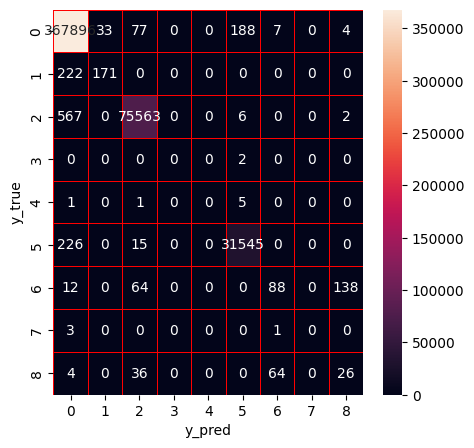

In [54]:
stk = xgb.XGBClassifier().fit(x_train, y_train)
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()